In [2]:
# Source: National Bank of Ukraine Exchange Rate Chart
# https://bank.gov.ua/en/markets/exchangerate-chart
# downloaded for USD/UAH historical rates xlsx
# PART A - UAH/USD descriptive summary
from pathlib import Path
import pandas as pd

#  File paths
# update if needed
input_file = Path("..") / "data" / "raw" / "USD_UAH_Historical_Data.xlsx"
output_dir = Path("..") / "outputs"
output_dir.mkdir(exist_ok=True)

#  Read the file
df = pd.read_excel(input_file)

# Keep only the useful columns
df = df[["Date", "Price"]].copy()

#  Rename columns
df = df.rename(columns={
    "Date": "date",
    "Price": "uah_per_usd"
})

# Convert date
df["date"] = pd.to_datetime(df["date"], format="%d.%m.%Y", errors="coerce")

# Convert exchange rate to numeric
df["uah_per_usd"] = pd.to_numeric(df["uah_per_usd"], errors="coerce")

#  Drop missing values and sort by date
df = df.dropna(subset=["date", "uah_per_usd"]).copy()
df = df.sort_values("date").reset_index(drop=True)

# Define the analytical periods for Part A
periods = [
    ("2000-01-01", "2001-12-31", "2000-2001"),
    ("2002-01-01", "2006-12-31", "2002-2006"),
    ("2007-01-01", "2007-12-31", "2007"),
    ("2008-01-01", "2009-12-31", "2008-2009"),
    ("2010-01-01", "2013-12-31", "2010-2013"),
    ("2014-01-01", "2015-12-31", "2014-2015"),
    ("2016-01-01", "2021-12-31", "2016-2021"),
    ("2022-01-01", "2023-12-31", "2022-2023"),
    ("2024-01-01", "2025-12-31", "2024-2025"),
]

# Function to summarize each period
def summarize_period(data, start, end, label):
    temp = data[(data["date"] >= start) & (data["date"] <= end)].copy()

    if temp.empty:
        return {
            "period": label,
            "first_value": None,
            "last_value": None,
            "min_value": None,
            "max_value": None,
            "mean_value": None,
            "n_obs": 0
        }

    return {
        "period": label,
        "first_value": round(temp.iloc[0]["uah_per_usd"], 4),
        "last_value": round(temp.iloc[-1]["uah_per_usd"], 4),
        "min_value": round(temp["uah_per_usd"].min(), 4),
        "max_value": round(temp["uah_per_usd"].max(), 4),
        "mean_value": round(temp["uah_per_usd"].mean(), 4),
        "n_obs": len(temp)
    }

# Build the summary table
summary = [summarize_period(df, start, end, label) for start, end, label in periods]
summary_df = pd.DataFrame(summary)

#  Show the result
print("\nSummary by period:")
print(summary_df.to_string(index=False))

#  Save the summary
output_file = output_dir / "uah_usd_summary_by_period.csv"
summary_df.to_csv(output_file, index=False)



Summary by period:
   period  first_value  last_value  min_value  max_value  mean_value  n_obs
2000-2001       5.2163      5.2985     5.2163     5.6029      5.4058    731
2002-2006       5.2985      5.0500     5.0500     5.3349      5.2305   1826
     2007       5.0500      5.0500     5.0500     5.0500      5.0500    365
2008-2009       5.0500      7.9850     4.8400     8.0148      6.5287    731
2010-2013       7.9850      7.9930     7.8861     8.0100      7.9718   1461
2014-2015       7.9930     24.0007     7.9930    30.0102     16.8693    730
2016-2021      24.0007     27.2782    23.2552    28.8758     26.5709   2192
2022-2023      27.2782     37.9824    27.2782    37.9824     34.4717    730
2024-2025      38.0020     42.3878    37.4521    42.4015     40.9235    731


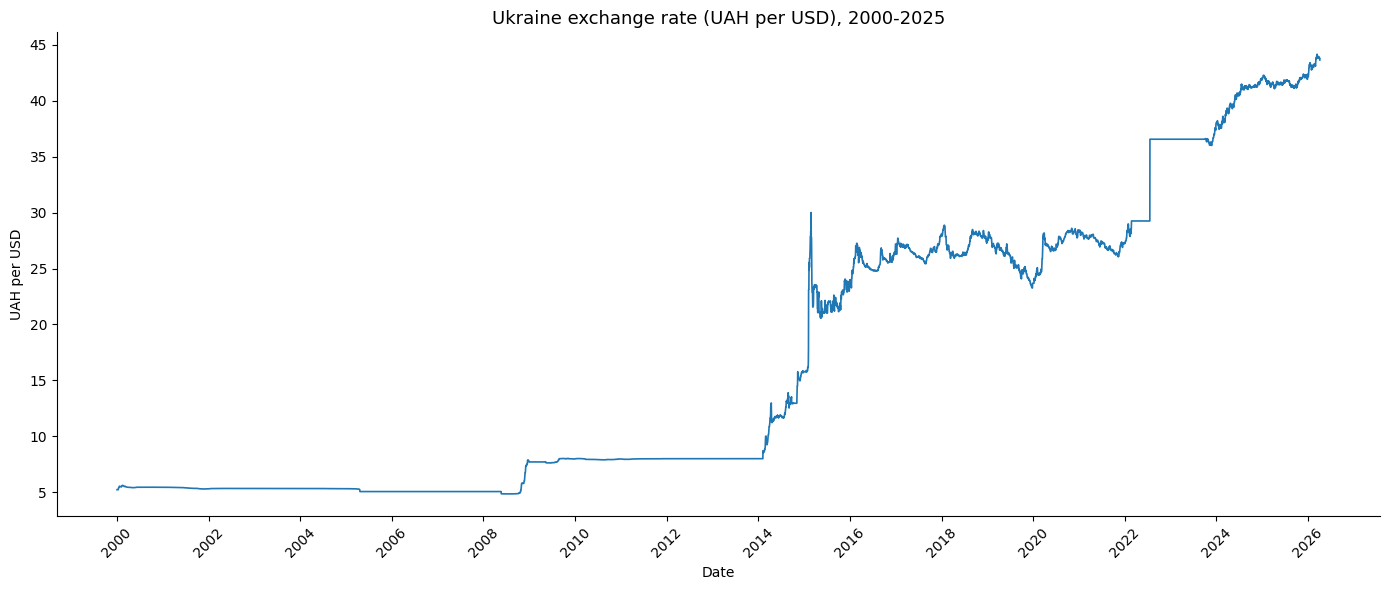

In [3]:
# UAH/USD chart
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Sort data
df = df.sort_values("date").copy()

# Create figure
fig, ax = plt.subplots(figsize=(14, 6), facecolor="white")
ax.set_facecolor("white")

# Plot series
ax.plot(df["date"], df["uah_per_usd"], linewidth=1.2)

# Titles and labels
ax.set_title("Ukraine exchange rate (UAH per USD), 2000-2025", fontsize=13)
ax.set_xlabel("Date")
ax.set_ylabel("UAH per USD")

# Remove grid
ax.grid(False)

# Show more years on x-axis
ax.xaxis.set_major_locator(mdates.YearLocator(2))   # every 2 years
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# Remove top and right borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.xticks(rotation=45)

# Tight layout
plt.tight_layout()

# Show figure
plt.show()

In [4]:
# Major devaluation episodes for Part A
# Important:
# The series is UAH per USD
# When this number increases, the hryvnia depreciates

episodes = [
    ("2008-01-01", "2009-12-31", "2008-2009", "Global financial crisis"),
    ("2014-01-01", "2015-12-31", "2014-2015", "Crimea annexation and Donbas conflict"),
    ("2022-01-01", "2022-12-31", "2022", "Full-scale invasion"),
]
# Function to compute depreciation measures inside each window
def compute_episode_metrics(data, start, end, label, trigger):
    temp = data[(data["date"] >= start) & (data["date"] <= end)].copy()
    temp = temp.sort_values("date").reset_index(drop=True)

    if temp.empty:
        return {
            "episode": label,
            "trigger": trigger,
            "window_start": start,
            "window_end": end,
            "first_date": None,
            "first_rate": None,
            "last_date": None,
            "last_rate": None,
            "max_date": None,
            "max_rate": None,
            "first_to_max_pct": None,
            "n_obs": 0
        }

    # First and last observations in the window
    first_date = temp.iloc[0]["date"]
    first_rate = temp.iloc[0]["uah_per_usd"]
    last_date = temp.iloc[-1]["date"]
    last_rate = temp.iloc[-1]["uah_per_usd"]


    # Minimum and maximum rate inside the window
    min_idx = temp["uah_per_usd"].idxmin()
    max_idx = temp["uah_per_usd"].idxmax()
    max_date = temp.loc[max_idx, "date"]
    max_rate = temp.loc[max_idx, "uah_per_usd"]

   

    # Change from first observation to peak
    first_to_max_pct = (max_rate / first_rate - 1) * 100

    return {
        "episode": label,
        "trigger": trigger,
        "window_start": pd.to_datetime(start).date(),
        "window_end": pd.to_datetime(end).date(),
        "first_date": first_date.date(),
        "first_rate": round(first_rate, 4),
        "last_date": last_date.date(),
        "last_rate": round(last_rate, 4),
        "max_date": max_date.date(),
        "max_rate": round(max_rate, 4),
        "first_to_max_pct": round(first_to_max_pct, 2),
        "n_obs": len(temp)
    }

# Build depreciation table
episodes_results = [
    compute_episode_metrics(df, start, end, label, trigger)
    for start, end, label, trigger in episodes
]
episodes_df = pd.DataFrame(episodes_results)

print("\nMajor devaluation episodes:")

print(episodes_df.to_string(index=False))
# Save depreciation table
episodes_output_file = output_dir / "uah_usd_devaluation_episodes.csv"
episodes_df.to_csv(episodes_output_file, index=False)



Major devaluation episodes:
  episode                               trigger window_start window_end first_date  first_rate  last_date  last_rate   max_date  max_rate  first_to_max_pct  n_obs
2008-2009               Global financial crisis   2008-01-01 2009-12-31 2008-01-01      5.0500 2009-12-31     7.9850 2009-11-05    8.0148             58.71    731
2014-2015 Crimea annexation and Donbas conflict   2014-01-01 2015-12-31 2014-01-01      7.9930 2015-12-31    24.0007 2015-02-26   30.0102            275.46    730
     2022                   Full-scale invasion   2022-01-01 2022-12-31 2022-01-01     27.2782 2022-12-31    36.5686 2022-07-21   36.5686             34.06    365
